✅ 2D Asset kaydedildi: ../../../assets\50_pid_2d.png


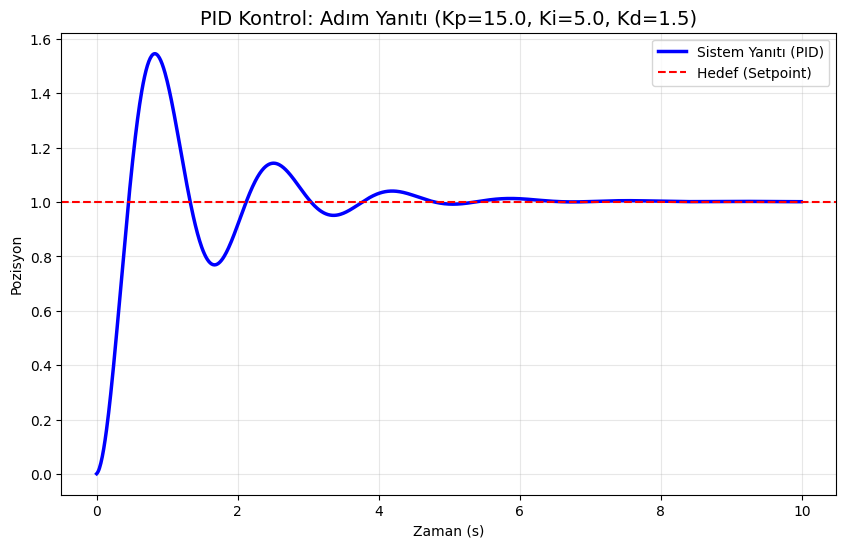

✅ 3D Asset kaydedildi: ../../../assets\50_pid_3d.png


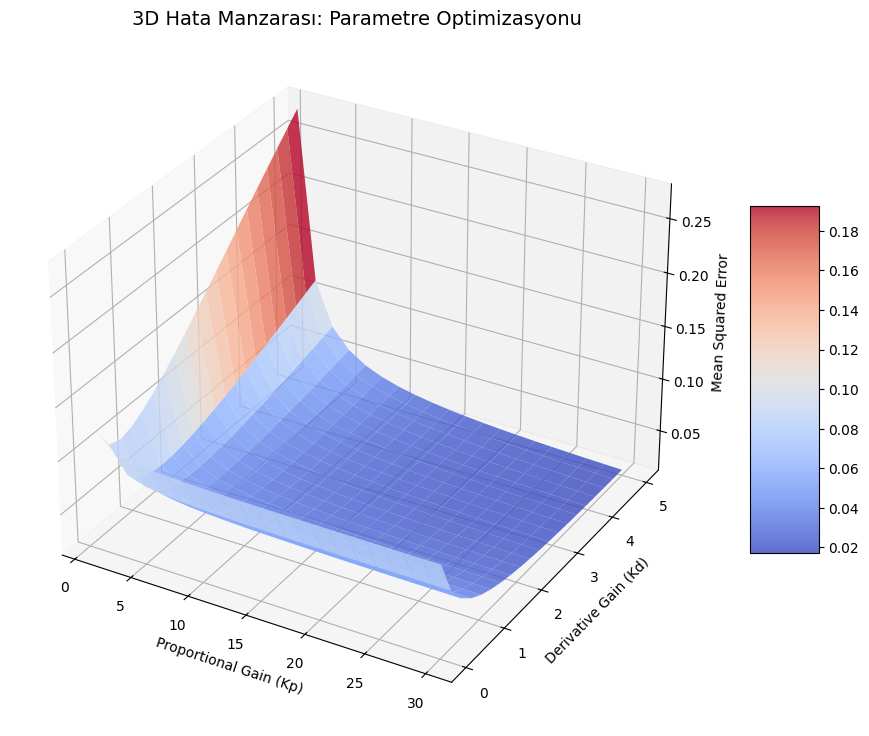

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_pid_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Sistem ve Kontrol Parametreleri
    dt = 0.01
    t_end = 10
    t = np.arange(0, t_end, dt)
    setpoint = 1.0 # Hedef değer
    
    # PID Katsayıları
    Kp, Ki, Kd = 15.0, 5.0, 1.5
    
    # 2. Simülasyon Fonksiyonu
    def simulate_pid(kp_in, ki_in, kd_in):
        curr_pos = 0.0
        curr_vel = 0.0
        integral = 0.0
        prev_error = setpoint - curr_pos
        
        pos_history = []
        for _ in t:
            error = setpoint - curr_pos
            integral += error * dt
            derivative = (error - prev_error) / dt
            
            # Kontrol sinyali
            u = kp_in * error + ki_in * integral + kd_in * derivative
            
            # Basit fizik motoru (F=ma, m=1)
            accel = u - 0.5 * curr_vel # Hava direnci ekleyelim
            curr_vel += accel * dt
            curr_pos += curr_vel * dt
            
            pos_history.append(curr_pos)
            prev_error = error
        return np.array(pos_history)

    # --- 📸 ASSET 1: STEP RESPONSE (50_pid_2d.png) ---
    fig1 = plt.figure(figsize=(10, 6))
    response = simulate_pid(Kp, Ki, Kd)
    plt.plot(t, response, 'b-', lw=2.5, label='Sistem Yanıtı (PID)')
    plt.axhline(setpoint, color='r', linestyle='--', label='Hedef (Setpoint)')
    plt.title(f"PID Kontrol: Adım Yanıtı (Kp={Kp}, Ki={Ki}, Kd={Kd})", fontsize=14)
    plt.xlabel("Zaman (s)"); plt.ylabel("Pozisyon")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '50_pid_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\50_pid_2d.png")
    plt.show()

    # --- 📸 ASSET 2: TUNING ERROR LANDSCAPE (50_pid_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    kp_vals = np.linspace(1, 30, 20)
    kd_vals = np.linspace(0, 5, 20)
    KP, KD = np.meshgrid(kp_vals, kd_vals)
    
    # Hata Yüzeyini Hesapla (MSE of response)
    Z_error = np.zeros_like(KP)
    for i in range(len(kd_vals)):
        for j in range(len(kp_vals)):
            res = simulate_pid(KP[i,j], 0.0, KD[i,j]) # Ki=0 basitleştirmesi
            Z_error[i,j] = np.mean((setpoint - res)**2)

    surf = ax3d.plot_surface(KP, KD, Z_error, cmap='coolwarm', alpha=0.8, edgecolor='none')
    ax3d.set_title("3D Hata Manzarası: Parametre Optimizasyonu", fontsize=14)
    ax3d.set_xlabel('Proportional Gain (Kp)'); ax3d.set_ylabel('Derivative Gain (Kd)')
    ax3d.set_zlabel('Mean Squared Error')
    
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)
    plt.savefig(os.path.join(asset_path, '50_pid_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\50_pid_3d.png")
    plt.show()

if __name__ == "__main__":
    run_pid_master()
